In [41]:
'''
与原书不同，原书中一个样本xi 为列向量，本代码中一个样本xi为行向量
尝试了两种优化方法，梯度下降和牛顿法。两者结果基本相同，不过有时因初始化的原因，
会导致牛顿法中海森矩阵为奇异矩阵，np.linalg.inv(hess)会报错。以后有机会再写拟牛顿法吧。
'''
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt 
from sklearn import linear_model
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
def sigmoid(x):
    s=1/(1+np.exp(-x))
    return s

#逻辑回归的损失函数 公式3.30
def J_cost(X,y,beta):
    '''
    :param X:  sample array, shape(n_samples, n_features)
    :param y: array-like, shape (n_samples,)
    :param beta: the beta in formula 3.27 , shape(n_features + 1, ) or (n_features + 1, 1)
    :return: the result of formula 3.27
    '''#给X额外拼上一列全1,(X.shape[0],X.shape[1]+1)
    X_hat=np.c_[X,np.ones((X.shape[0],1))] 
    #把beta和y都reshape成列向量,方便后面矩阵乘法
    #β=(β0​,β1​,…,βd​)^T
    beta=beta.reshape(-1,1) #(X.shape[1]+1,1)
    y=y.reshape(-1,1)  #(X.shape[0],1)
    #z_i=x^hat_i^T*β,pi​=1/1+e^−zi​​
    p1=sigmoid(np.dot(X_hat,beta)) #(X.shape[0],1)

    #Li​(β)=−yi​zi​+log(1+e^zi​)
    gra=(-X_hat*(y-p1)).sum(axis=0) 
    #-X_hat.shape=(X.shape[0],X.shape[1]+1)
    #y-p1.shape=(X.shape[0],1)numpy广播成(X.shape[0],X.shape[1]+1)
    '''
    y-p=[0.1
        -0.2
        0.3]
    ​变成
    [0.1 0.1 0.1
    -0.2 -0.2 -0.2
    0.3 0.3 0.3
    ]
    '''
    #然后相乘得(X.shape[0],X.shape[1]+1)
    #.sum(axis=0)=(X.shape[1]+1,)
    return gra.reshape(-1,1) #(X.shape[1]+1,1)

In [5]:
def hessian(X,y,beta):
    """
    计算J的二阶导数（即公式3.27）关于β的导数，对应公式3.31
    ----------------------------------
    :参数 X: 样本数组，维度(样本数量, 特征数量)
    :参数 y: 类数组数据，维度(样本数量,)
    :参数 beta: 公式3.27中的β，维度(特征数量 + 1, ) 或 (特征数量 + 1, 1)
    :返回值:
    """
    X_hat=np.c_[X,np.ones((X.shape[0],1))] #(X.shape[0],X.shape[1]+1)
    beta=beta.reshape(-1,1) #(X.shape[1]+1,1)
    y=y.reshape(-1,1)

    p1=sigmoid(np.dot(X_hat,beta)) #(X.shape[0],1)
    m,n=X.shape 
    P=np.eye(m)*p1*(1-p1) #(X.shape[0],X.shape[0])

    assert P.shape[0]==P.shape[1]
    return np.dot(np.dot(X_hat.T,P),X_hat) #(X.shape[0]+1,X.shape[0]+1)

In [6]:
def update_parameters_newton(X,y,beta,num_iterations,print_cost):
    '''
    使用牛顿法更新参数
    :参数 beta:
    :参数 grad:
    :参数 hess:
    :返回值:
    '''
    for i in range(num_iterations):
        grad=J_cost(X,y,beta)
        hess=hessian(X,y,beta)
        beta=beta-np.dot(np.linalg.inv(hess),grad)

        if(i%10==0)&print_cost:
            print("第",i,"次迭代的损失函数值为:",J_cost(X,y,beta))
    return beta

In [7]:
def update_parameters_gradDesc(X,y,beta,learning_rate,num_iterations,print_cost):
    '''
    使用梯度下降法更新参数
    :参数 beta:
    :参数 grad:
    :返回值:
    '''
    for i in range(num_iterations):
        grad=J_cost(X,y,beta)
        beta=beta-learning_rate*grad

        if(i%10==0)&print_cost:
            print("第",i,"次迭代的损失函数值为:",J_cost(X,y,beta))
    return beta

In [46]:
def initialize_beta(n):
    beta=np.random.randn(n+1,1)*0.5+1
    return beta

def logistic_model(X,y,num_iterations=100,learning_rate=1.2,print_cost=False,method='gradDesc'):
    '''
    :param X:
    :param y:~
    :param num_iterations:
    :param learning_rate:
    :param print_cost:
    :param method: str 'gradDesc' or 'Newton'
    :return:
    '''
    m,n=X.shape
    beta=initialize_beta(n)
    
    if method=='gradDesc':
        return update_parameters_gradDesc(X,y,beta,learning_rate,num_iterations,print_cost)
    elif method=='Newton':
        return update_parameters_newton(X,y,beta,num_iterations,print_cost)
    else:
        raise ValueError("method must be 'gradDesc' or 'Newton'")

In [9]:
def predict(X,beta):
    '''
    :param X:
    :param beta:
    :return: 预测的概率值
    '''
    X_hat=np.c_[X,np.ones((X.shape[0],1))] #(X.shape[0],X.shape[1]+1)
    p1=sigmoid(np.dot(X_hat,beta)) #(X.shape[0],1)
    p1[p1>=0.5]=1
    p1[p1<0.5]=0
    
    return p1

[[1 '青绿' '蜷缩' '浊响' '清晰' '凹陷' '硬滑' 0.697 0.46 '是']
 [2 '乌黑' '蜷缩' '沉闷' '清晰' '凹陷' '硬滑' 0.774 0.376 '是']
 [3 '乌黑' '蜷缩' '浊响' '清晰' '凹陷' '硬滑' 0.634 0.264 '是']
 [4 '青绿' '蜷缩' '沉闷' '清晰' '凹陷' '硬滑' 0.608 0.318 '是']
 [5 '浅白' '蜷缩' '浊响' '清晰' '凹陷' '硬滑' 0.556 0.215 '是']
 [6 '青绿' '稍蜷' '浊响' '清晰' '稍凹' '软粘' 0.403 0.237 '是']
 [7 '乌黑' '稍蜷' '浊响' '稍糊' '稍凹' '软粘' 0.481 0.149 '是']
 [8 '乌黑' '稍蜷' '浊响' '清晰' '稍凹' '硬滑' 0.437 0.211 '是']
 [9 '乌黑' '稍蜷' '沉闷' '稍糊' '稍凹' '硬滑' 0.666 0.091 '否']
 [10 '青绿' '硬挺' '清脆' '清晰' '平坦' '软粘' 0.243 0.267 '否']
 [11 '浅白' '硬挺' '清脆' '模糊' '平坦' '硬滑' 0.245 0.057 '否']
 [12 '浅白' '蜷缩' '浊响' '模糊' '平坦' '软粘' 0.343 0.099 '否']
 [13 '青绿' '稍蜷' '浊响' '稍糊' '凹陷' '硬滑' 0.639 0.161 '否']
 [14 '浅白' '稍蜷' '沉闷' '稍糊' '凹陷' '硬滑' 0.657 0.198 '否']
 [15 '乌黑' '稍蜷' '浊响' '清晰' '稍凹' '软粘' 0.36 0.37 '否']
 [16 '浅白' '蜷缩' '浊响' '模糊' '平坦' '硬滑' 0.593 0.042 '否']
 [17 '青绿' '蜷缩' '沉闷' '稍糊' '稍凹' '硬滑' 0.719 0.103 '否']]
(17, 2)
w1: [3.15236694] w2: [12.49857383] intercept: [-4.42101644]


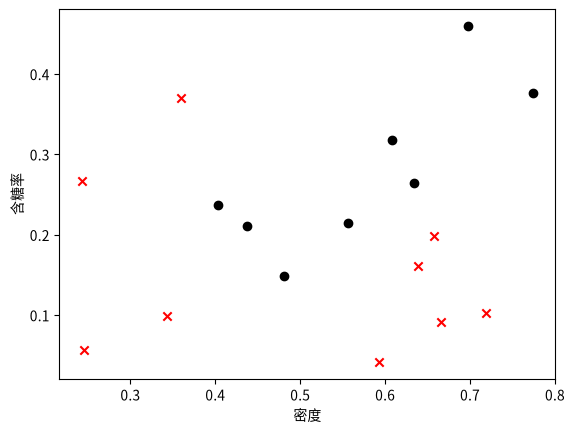

In [ ]:
if __name__=="__main__":
    data_path="watermelon3_0_Ch.csv"
    data=pd.read_csv(data_path).values
    print(data)
    is_good=data[:, 9]=='是' #是否是好瓜
    is_bad=data[:, 9]=='否' #是否是坏瓜
    X=data[:,7:9].astype(float) #密度和含糖率
    y=data[:,9]

    y[y=='是']=1
    y[y=='否']=0
    y=y.astype(int)
    plt.scatter(data[:,7][is_good],data[:,8][is_good],c='k',marker='o')
    plt.scatter(data[:,7][is_bad],data[:,8][is_bad],c='r',marker='x')

    plt.xlabel('密度')
    plt.ylabel('含糖率')

    #可视化模型结果
    beta=logistic_model(X,y,print_cost=False,method='gradDesc',learning_rate=0.3,num_iterations=1000)
    w1,w2,intercept=beta
    #print("w1:",w1,"w2:",w2,"intercept:",intercept)
    x1=np.linspace(0,1) #默认生成50个0-1的点
    y1=-(w1*x1+intercept)/w2
    